In [ ]:
#camscanner
#image transformation -Translate,Rotate,Resize
#perspective transform

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img=cv2.imread('D:\\chat-app\\old-book-page-antique-paper-sheet-DX99RB.jpg')


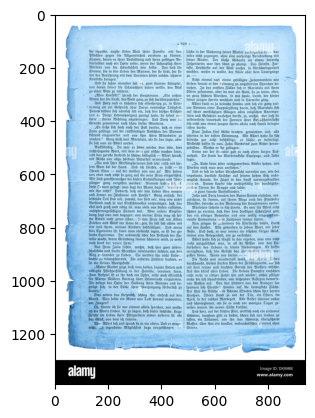

In [6]:
plt.imshow(img)

In [7]:
img.shape

(1390, 942, 3)

In [8]:
rows,cols =img.shape[:2]

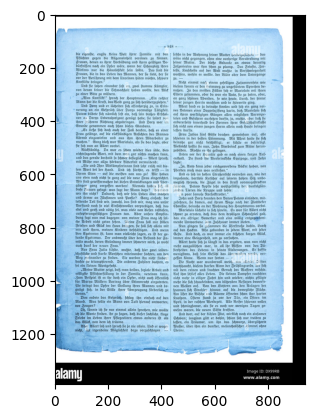

In [11]:
#Translate image
#create translate matrix
#format: [[1,0,tx],[0,1,ty]]
#tx-shift along x-axis
#ty-shift along y-axis
matrix=np.float32([[1,0,-50],[0,1,10]])
#apply translation
#param:(image,translate_matrix,output_size)
translate=cv2.warpAffine(img,matrix,(cols,rows))
plt.imshow(translate)
plt.show()

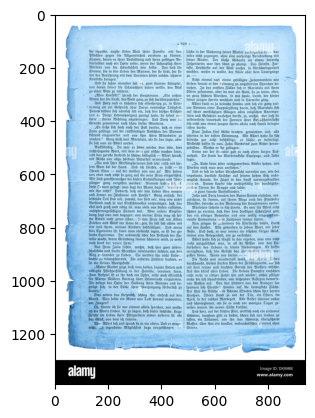

In [14]:
#rotation

#center of rotation
center=(rows//2,cols//2)
#params:(center,angle,scale)
#angle -rotation in degrees (positive=counter clockwise)
#scale-zoom(default=1)
matrix=cv2.getRotationMatrix2D(center,360,1)
rotated=cv2.warpAffine(img,matrix,(cols,rows))
plt.imshow(rotated)

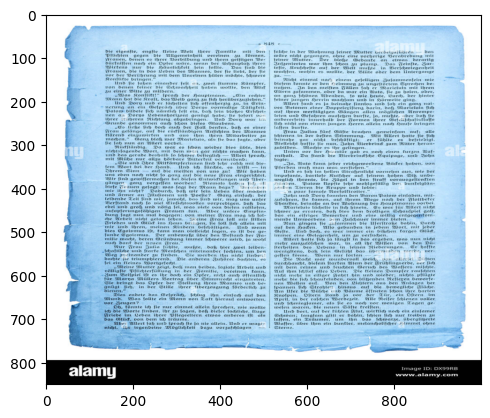

In [18]:
#resize image
resized=cv2.resize(rotated,(1000,850))
plt.imshow(resized)
plt.show()

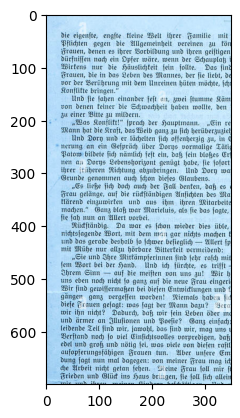

In [29]:
#rotated[start_y:end_y,start_x:end_x]
#first =rows[height-y]
#second =cols[width-x]
cropped=rotated[100:800,100:450]
plt.imshow(cropped)
plt.show()

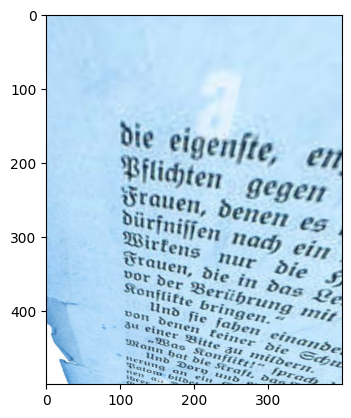

In [33]:
#perspective convert tilted image to top-down  flat view
#source points:[top-left,top-right,bottom-right,bottom-left]
points1=np.float32([[100,100],[200,100],[300,300],[0,500]])
#destination points
points2=np.float32([[0,0],[400,0],[400,500],[0,500]])
#compute perspective transform matrix
matrix=cv2.getPerspectiveTransform(points1,points2)
warped=cv2.warpPerspective(img,matrix,[400,500])
plt.imshow(warped)
plt.show()